Imports & Configuration

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Project paths
DATA_DIR = os.path.join('..', 'data', 'raw')
PROC_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'report', 'figures')

for d in [DATA_DIR, PROC_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)

print(" Imports and paths ready.")

 Imports and paths ready.


Generate Synthetic Drone Telemetry Dataset

In [2]:
def generate_drone_telemetry(n_samples=5000, n_drones=10, grid_size=10, seed=42):
    """
    Generate synthetic drone telemetry with realistic feature distributions.
    Anomaly labels are assigned via deterministic threshold rules.
    """
    np.random.seed(seed)

    records = []
    for i in range(n_samples):
        drone_id = f"D{i % n_drones + 1}"

        # --- Normal telemetry ---
        step = i // n_drones
        battery_level = np.clip(np.random.normal(75, 15), 5, 100)

        # Battery drop: normally 1-5 %, can spike for anomalies
        is_battery_anomaly = np.random.rand() < 0.12
        if is_battery_anomaly:
            battery_drop = np.random.uniform(31, 60)     # > 30 %
        else:
            battery_drop = np.random.uniform(1, 5)

        # Altitude and speed
        altitude = np.clip(np.random.normal(50, 10), 10, 100)
        speed = np.clip(np.random.normal(8, 2), 1, 20)

        # Altitude / speed change
        is_sensor_spike = np.random.rand() < 0.10
        if is_sensor_spike:
            altitude_change = np.random.uniform(16, 40)   # > 15 m
            speed_change    = np.random.uniform(9, 18)     # > 8 m/s
        else:
            altitude_change = np.random.uniform(0.5, 5)
            speed_change    = np.random.uniform(0.2, 3)

        # Route deviation
        is_route_anomaly = np.random.rand() < 0.11
        if is_route_anomaly:
            route_deviation = np.random.uniform(6, 15)    # > 5 cells
        else:
            route_deviation = np.random.uniform(0, 2)

        # Planned and actual positions
        planned_x = np.random.randint(0, grid_size)
        planned_y = np.random.randint(0, grid_size)
        actual_x  = int(np.clip(planned_x + np.random.choice([-1, 0, 0, 0, 1]) + int(route_deviation * np.random.choice([-1, 1]) * 0.3), 0, grid_size - 1))
        actual_y  = int(np.clip(planned_y + np.random.choice([-1, 0, 0, 0, 1]) + int(route_deviation * np.random.choice([-1, 1]) * 0.3), 0, grid_size - 1))

        # ---- ASSIGN LABEL using deterministic threshold rules ----
        # Priority: Battery > Route > Sensor > Normal
        if battery_drop > 30:
            label = "Battery Anomaly"
        elif route_deviation > 5:
            label = "Route Anomaly"
        elif altitude_change > 15 or speed_change > 8:
            label = "Sensor Spike"
        else:
            label = "Normal"

        records.append({
            'drone_id': drone_id,
            'step': step,
            'battery_level': round(battery_level, 1),
            'battery_drop': round(battery_drop, 2),
            'altitude': round(altitude, 1),
            'altitude_change': round(altitude_change, 2),
            'speed': round(speed, 1),
            'speed_change': round(speed_change, 2),
            'planned_x': planned_x,
            'planned_y': planned_y,
            'actual_x': actual_x,
            'actual_y': actual_y,
            'route_deviation': round(route_deviation, 2),
            'anomaly_type': label
        })

    df = pd.DataFrame(records)
    return df

# Generate
df = generate_drone_telemetry(n_samples=5000)
print(f" Synthetic telemetry generated — {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Class distribution:")
print(df['anomaly_type'].value_counts())
df.head(10)

 Synthetic telemetry generated — 5000 rows × 14 columns

Class distribution:
anomaly_type
Normal             3543
Battery Anomaly     606
Route Anomaly       471
Sensor Spike        380
Name: count, dtype: int64


,drone_id,step,battery_level,battery_drop,altitude,altitude_change,speed,speed_change,planned_x,planned_y,actual_x,actual_y,route_deviation,anomaly_type
0,D1,0,82.5,3.39,48.6,36.79,7.5,14.41,1,7,1,7,0.04,Sensor Spike
1,D2,0,71.5,3.47,50.2,0.71,7.1,2.93,2,6,2,5,0.18,Normal
2,D3,0,81.3,1.05,58.3,0.57,8.2,0.85,7,2,6,2,1.37,Normal
3,D4,0,85.0,2.70,53.2,36.21,5.2,13.05,7,6,7,7,1.85,Sensor Spike
4,D5,0,79.0,4.86,66.4,1.24,5.0,0.24,7,7,7,6,0.79,Normal
5,D6,0,85.8,4.09,47.9,4.38,6.8,1.95,6,7,7,7,0.13,Normal
6,D7,0,81.9,4.89,33.2,1.65,8.9,0.31,2,6,1,7,0.22,Normal
7,D8,0,86.0,1.56,58.7,4.74,12.6,1.88,9,8,9,8,1.76,Normal
8,D9,0,68.8,2.30,36.0,1.72,7.3,2.01,2,6,0,5,9.17,Route Anomaly
9,D10,0,62.1,40.79,48.4,3.66,8.8,1.22,6,1,6,2,1.92,Battery Anomaly


Label Rule Verification

In [3]:
def verify_label(row):
    if row['battery_drop'] > 30:
        return "Battery Anomaly"
    elif row['route_deviation'] > 5:
        return "Route Anomaly"
    elif row['altitude_change'] > 15 or row['speed_change'] > 8:
        return "Sensor Spike"
    else:
        return "Normal"

df['verified'] = df.apply(verify_label, axis=1)
mismatches = (df['anomaly_type'] != df['verified']).sum()
print(f"Mismatched labels: {mismatches} / {len(df)}")
df.drop(columns='verified', inplace=True)

Mismatched labels: 0 / 5000


 Exploratory Data Analysis

In [4]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution (%):\n", df['anomaly_type'].value_counts(normalize=True).round(3) * 100)

Shape: (5000, 14)

Missing values:
 drone_id           0
step               0
battery_level      0
battery_drop       0
altitude           0
altitude_change    0
speed              0
speed_change       0
planned_x          0
planned_y          0
actual_x           0
actual_y           0
route_deviation    0
anomaly_type       0
dtype: int64

Class distribution (%):
 anomaly_type
Normal             70.9
Battery Anomaly    12.1
Route Anomaly       9.4
Sensor Spike        7.6
Name: proportion, dtype: float64


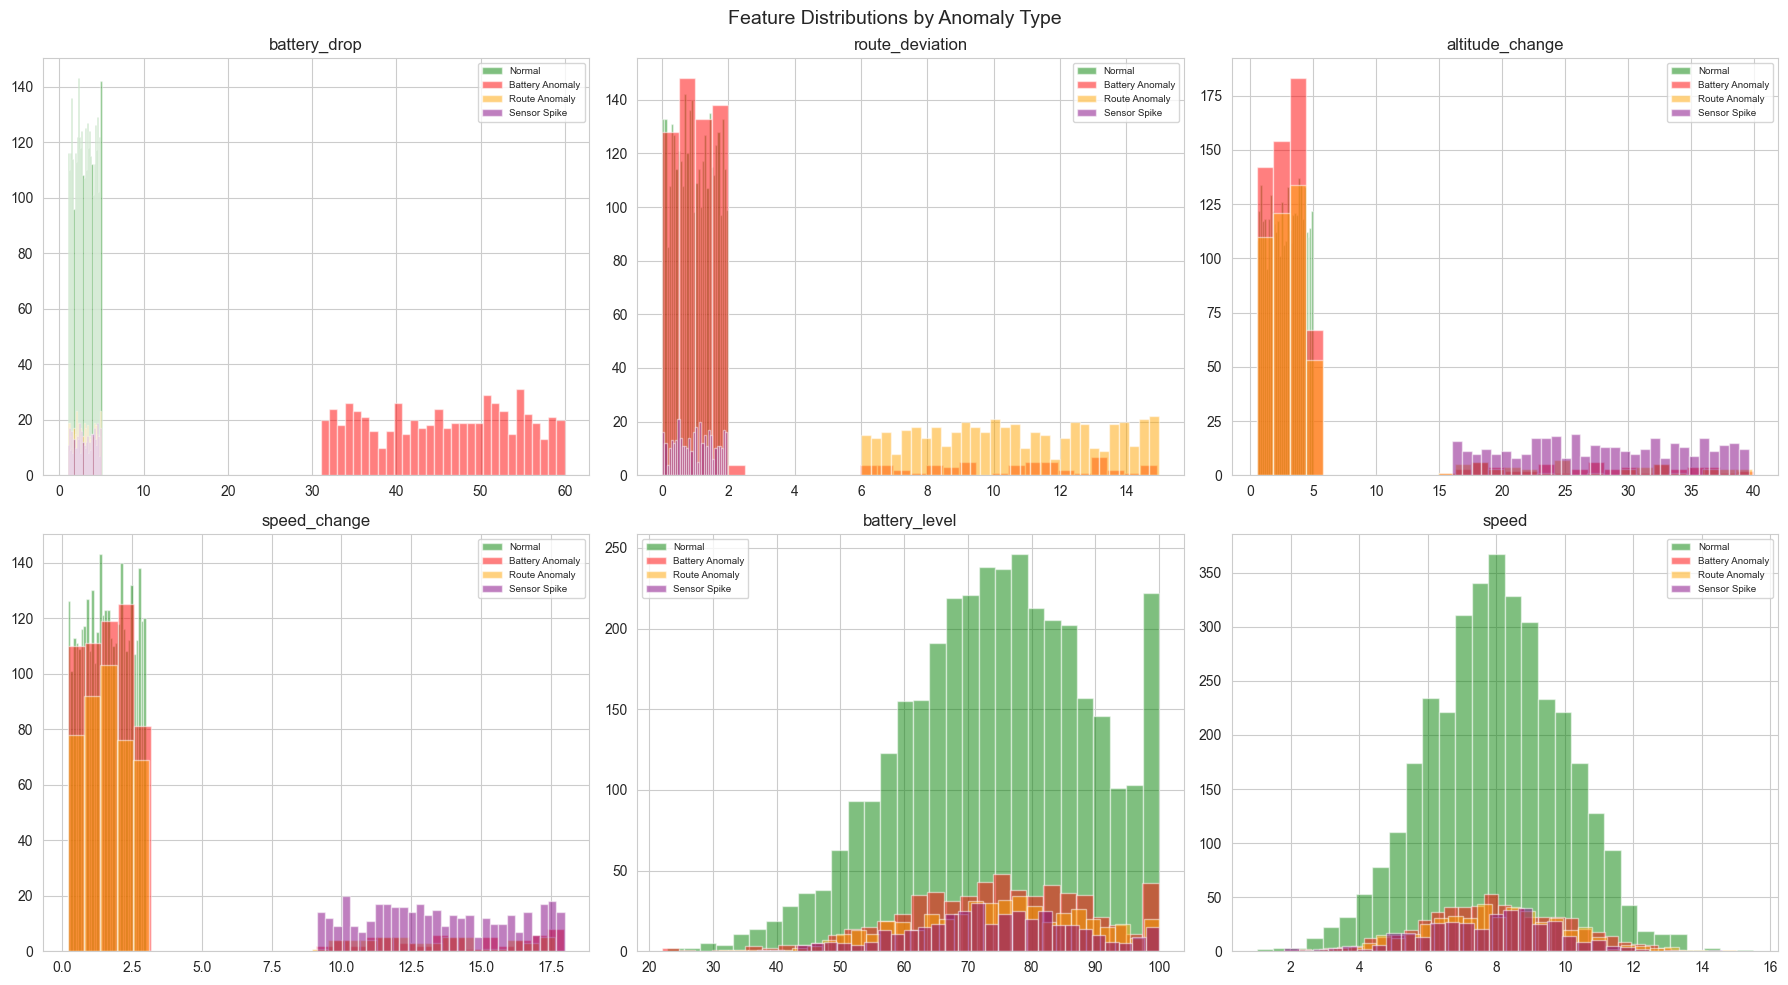

Feature distribution figure saved.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_plot = ['battery_drop', 'route_deviation', 'altitude_change',
                    'speed_change', 'battery_level', 'speed']
colors = {'Normal': 'green', 'Battery Anomaly': 'red',
          'Route Anomaly': 'orange', 'Sensor Spike': 'purple'}

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    for label, color in colors.items():
        subset = df[df['anomaly_type'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.5, label=label, color=color)
    ax.set_title(feat)
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Anomaly Type', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'anomaly_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Feature distribution figure saved.")

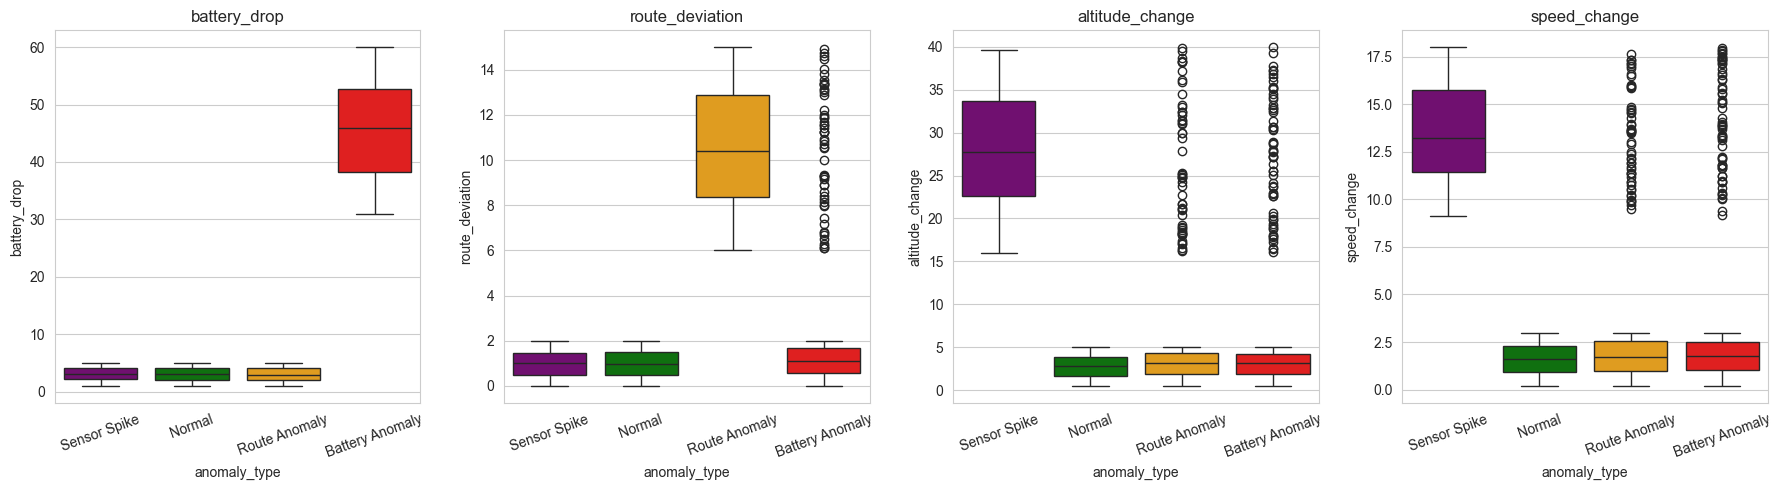

In [6]:
# Box plots for key features
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
key_features = ['battery_drop', 'route_deviation', 'altitude_change', 'speed_change']
for i, feat in enumerate(key_features):
    sns.boxplot(data=df, x='anomaly_type', y=feat, ax=axes[i], palette=colors)
    axes[i].set_title(feat)
    axes[i].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'anomaly_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

Feature Selection

In [7]:
feature_cols = ['battery_level', 'battery_drop', 'altitude', 'altitude_change',
                'speed', 'speed_change', 'route_deviation']
target_col = 'anomaly_type'

X = df[feature_cols].copy()
y = df[target_col].copy()

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
label_names = le.classes_

print(f"Features : {feature_cols}")
print(f"Labels   : {list(label_names)}")
print(f"Encoded  : {list(range(len(label_names)))}")
print(f"\nClass distribution:\n{pd.Series(y).value_counts()}")
X.head()

Features : ['battery_level', 'battery_drop', 'altitude', 'altitude_change', 'speed', 'speed_change', 'route_deviation']
Labels   : ['Battery Anomaly', 'Normal', 'Route Anomaly', 'Sensor Spike']
Encoded  : [0, 1, 2, 3]

Class distribution:
anomaly_type
Normal             3543
Battery Anomaly     606
Route Anomaly       471
Sensor Spike        380
Name: count, dtype: int64


,battery_level,battery_drop,altitude,altitude_change,speed,speed_change,route_deviation
0,82.5,3.39,48.6,36.79,7.5,14.41,0.04
1,71.5,3.47,50.2,0.71,7.1,2.93,0.18
2,81.3,1.05,58.3,0.57,8.2,0.85,1.37
3,85.0,2.70,53.2,36.21,5.2,13.05,1.85
4,79.0,4.86,66.4,1.24,5.0,0.24,0.79


Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training : {X_train.shape[0]} samples")
print(f"Testing  : {X_test.shape[0]} samples")

Training : 4000 samples
Testing  : 1000 samples


Model 1: Decision Tree Classifier

In [9]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)                   # tree models don't need scaling

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt, average='weighted')

print("Decision Tree Results")
print(f"  Accuracy = {acc_dt:.4f}")
print(f"  F1 (weighted) = {f1_dt:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=label_names))

Decision Tree Results
  Accuracy = 1.0000
  F1 (weighted) = 1.0000

Classification Report:
                 precision    recall  f1-score   support

Battery Anomaly       1.00      1.00      1.00       121
         Normal       1.00      1.00      1.00       709
  Route Anomaly       1.00      1.00      1.00        94
   Sensor Spike       1.00      1.00      1.00        76

       accuracy                           1.00      1000
      macro avg       1.00      1.00      1.00      1000
   weighted avg       1.00      1.00      1.00      1000



Model 2: Random Forest Classifier

In [10]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')

print("Random Forest Results")
print(f"  Accuracy = {acc_rf:.4f}")
print(f"  F1 (weighted) = {f1_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=label_names))

Random Forest Results
  Accuracy = 1.0000
  F1 (weighted) = 1.0000

Classification Report:
                 precision    recall  f1-score   support

Battery Anomaly       1.00      1.00      1.00       121
         Normal       1.00      1.00      1.00       709
  Route Anomaly       1.00      1.00      1.00        94
   Sensor Spike       1.00      1.00      1.00        76

       accuracy                           1.00      1000
      macro avg       1.00      1.00      1.00      1000
   weighted avg       1.00      1.00      1.00      1000



Model 3: K-Nearest Neighbors (Comparison)

In [11]:
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train_scaled, y_train)           # KNN needs scaled features

y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn, average='weighted')

print("KNN Results")
print(f"  Accuracy = {acc_knn:.4f}")
print(f"  F1 (weighted) = {f1_knn:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=label_names))

KNN Results
  Accuracy = 0.9980
  F1 (weighted) = 0.9980

Classification Report:
                 precision    recall  f1-score   support

Battery Anomaly       1.00      0.99      1.00       121
         Normal       1.00      1.00      1.00       709
  Route Anomaly       0.99      0.99      0.99        94
   Sensor Spike       0.99      1.00      0.99        76

       accuracy                           1.00      1000
      macro avg       0.99      1.00      0.99      1000
   weighted avg       1.00      1.00      1.00      1000



Model 4: Naive Bayes (Extra Comparison)


In [12]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb  = f1_score(y_test, y_pred_nb, average='weighted')

print("Naive Bayes Results")
print(f"  Accuracy = {acc_nb:.4f}")
print(f"  F1 (weighted) = {f1_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=label_names))

Naive Bayes Results
  Accuracy = 1.0000
  F1 (weighted) = 1.0000

Classification Report:
                 precision    recall  f1-score   support

Battery Anomaly       1.00      1.00      1.00       121
         Normal       1.00      1.00      1.00       709
  Route Anomaly       1.00      1.00      1.00        94
   Sensor Spike       1.00      1.00      1.00        76

       accuracy                           1.00      1000
      macro avg       1.00      1.00      1.00      1000
   weighted avg       1.00      1.00      1.00      1000



Model Comparison Table

        Model  Accuracy  F1 (weighted)
Decision Tree     1.000          1.000
Random Forest     1.000          1.000
          KNN     0.998          0.998
  Naive Bayes     1.000          1.000


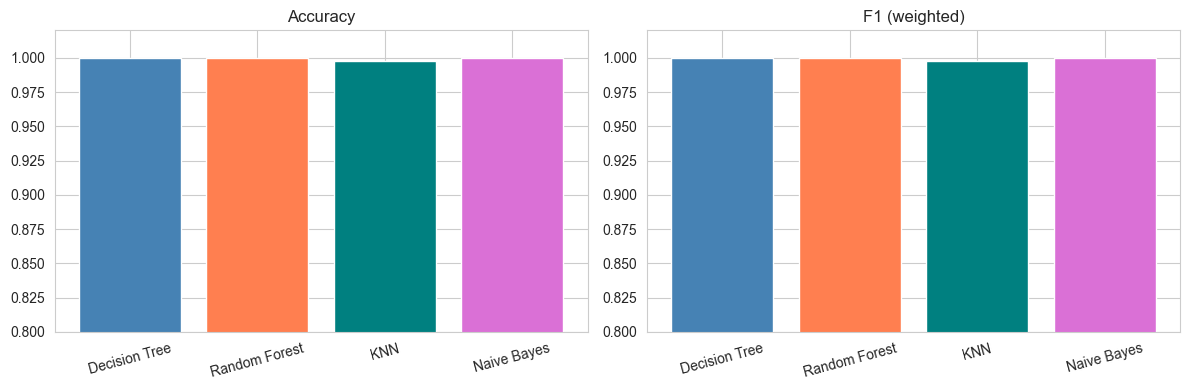

In [13]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes'],
    'Accuracy': [acc_dt, acc_rf, acc_knn, acc_nb],
    'F1 (weighted)': [f1_dt, f1_rf, f1_knn, f1_nb]
}).round(4)

print(comparison.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, metric in enumerate(['Accuracy', 'F1 (weighted)']):
    axes[i].bar(comparison['Model'], comparison[metric], color=['steelblue', 'coral', 'teal', 'orchid'])
    axes[i].set_title(metric)
    axes[i].set_ylim(0.8, 1.02)
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'anomaly_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

 Confusion Matrices

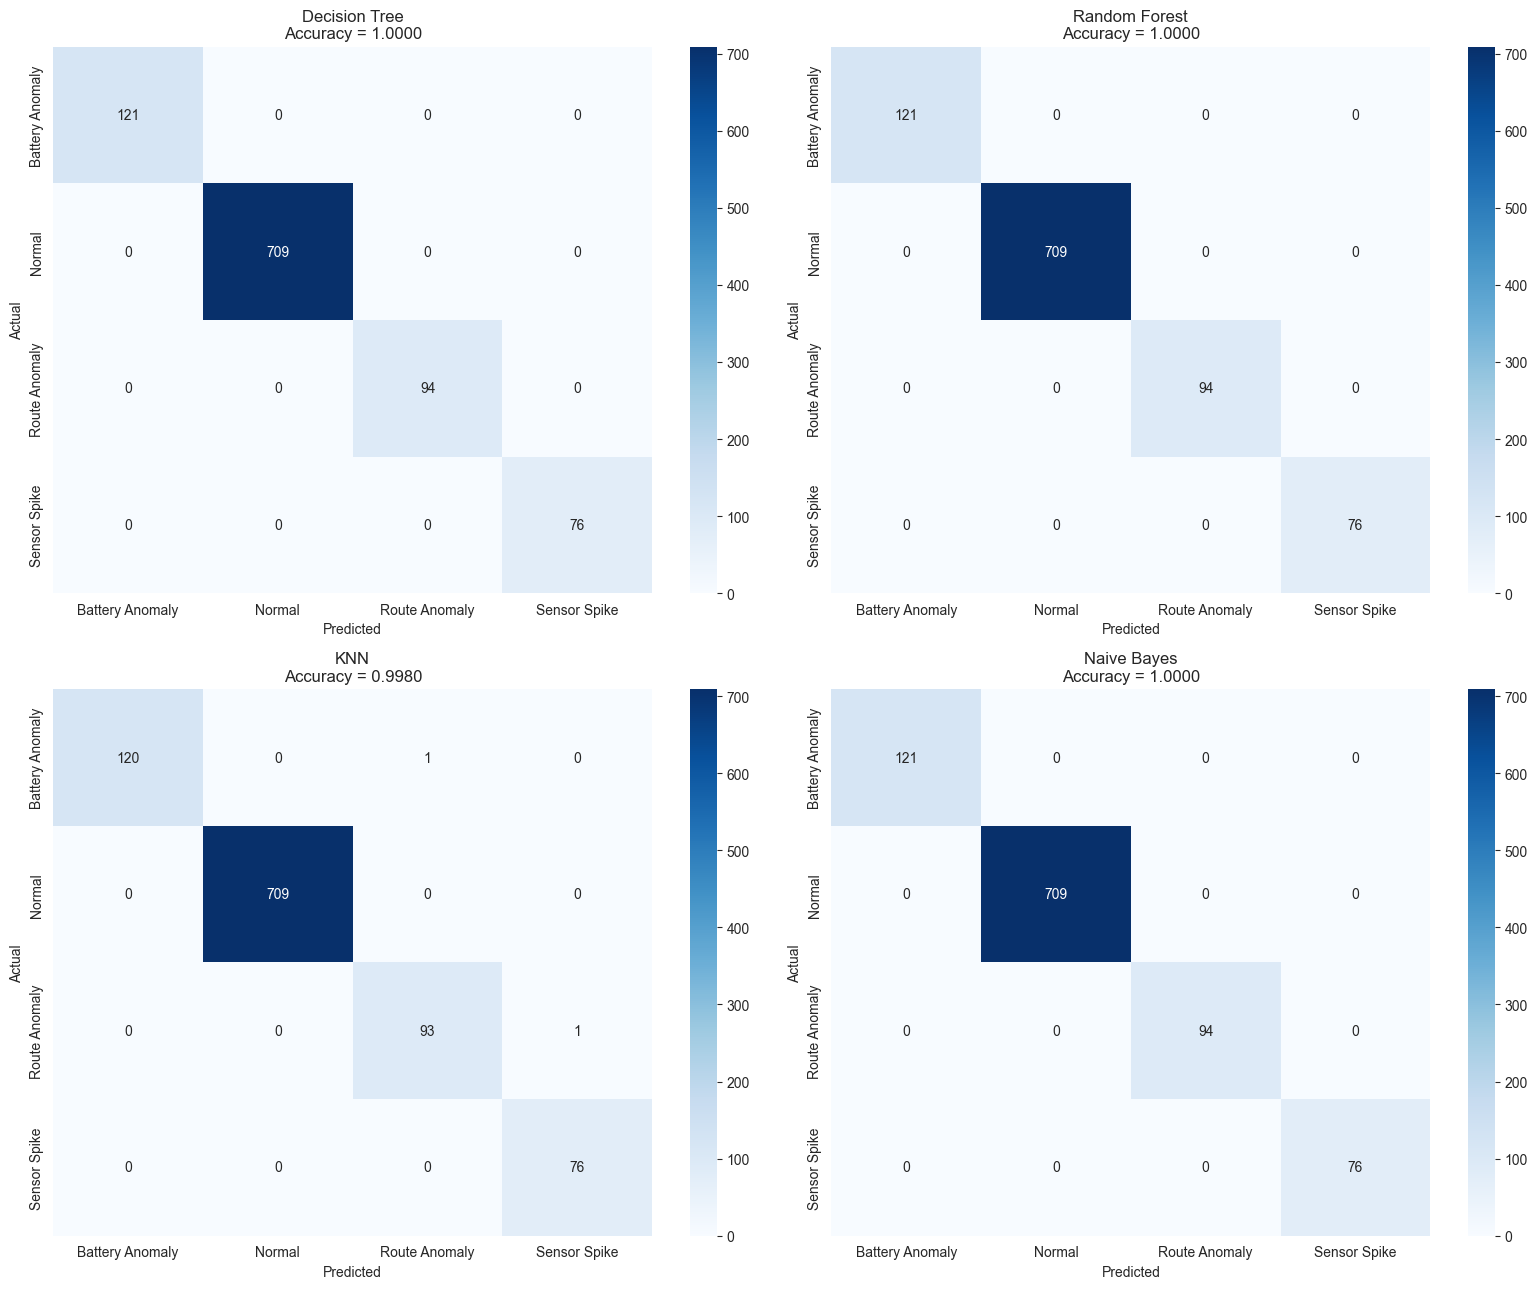

 Confusion matrices saved → report/figures/anomaly_confusion_matrices.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

models = {
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb
}

for idx, (name, y_pred) in enumerate(models.items()):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f'{name}\nAccuracy = {accuracy_score(y_test, y_pred):.4f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'anomaly_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrices saved → report/figures/anomaly_confusion_matrices.png")

 Feature Importance (Random Forest)

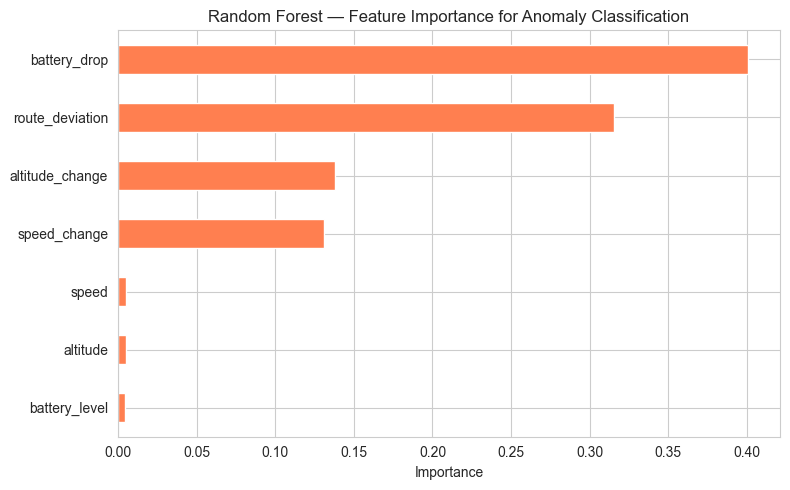

Top features:
 battery_drop       0.401035
route_deviation    0.315600
altitude_change    0.137691
speed_change       0.131037
speed              0.005133
altitude           0.004877
battery_level      0.004628
dtype: float64


In [15]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot.barh(color='coral')
plt.title('Random Forest — Feature Importance for Anomaly Classification')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'anomaly_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Top features:\n", importances.sort_values(ascending=False))

Decision Tree Visualization (Interpretability)

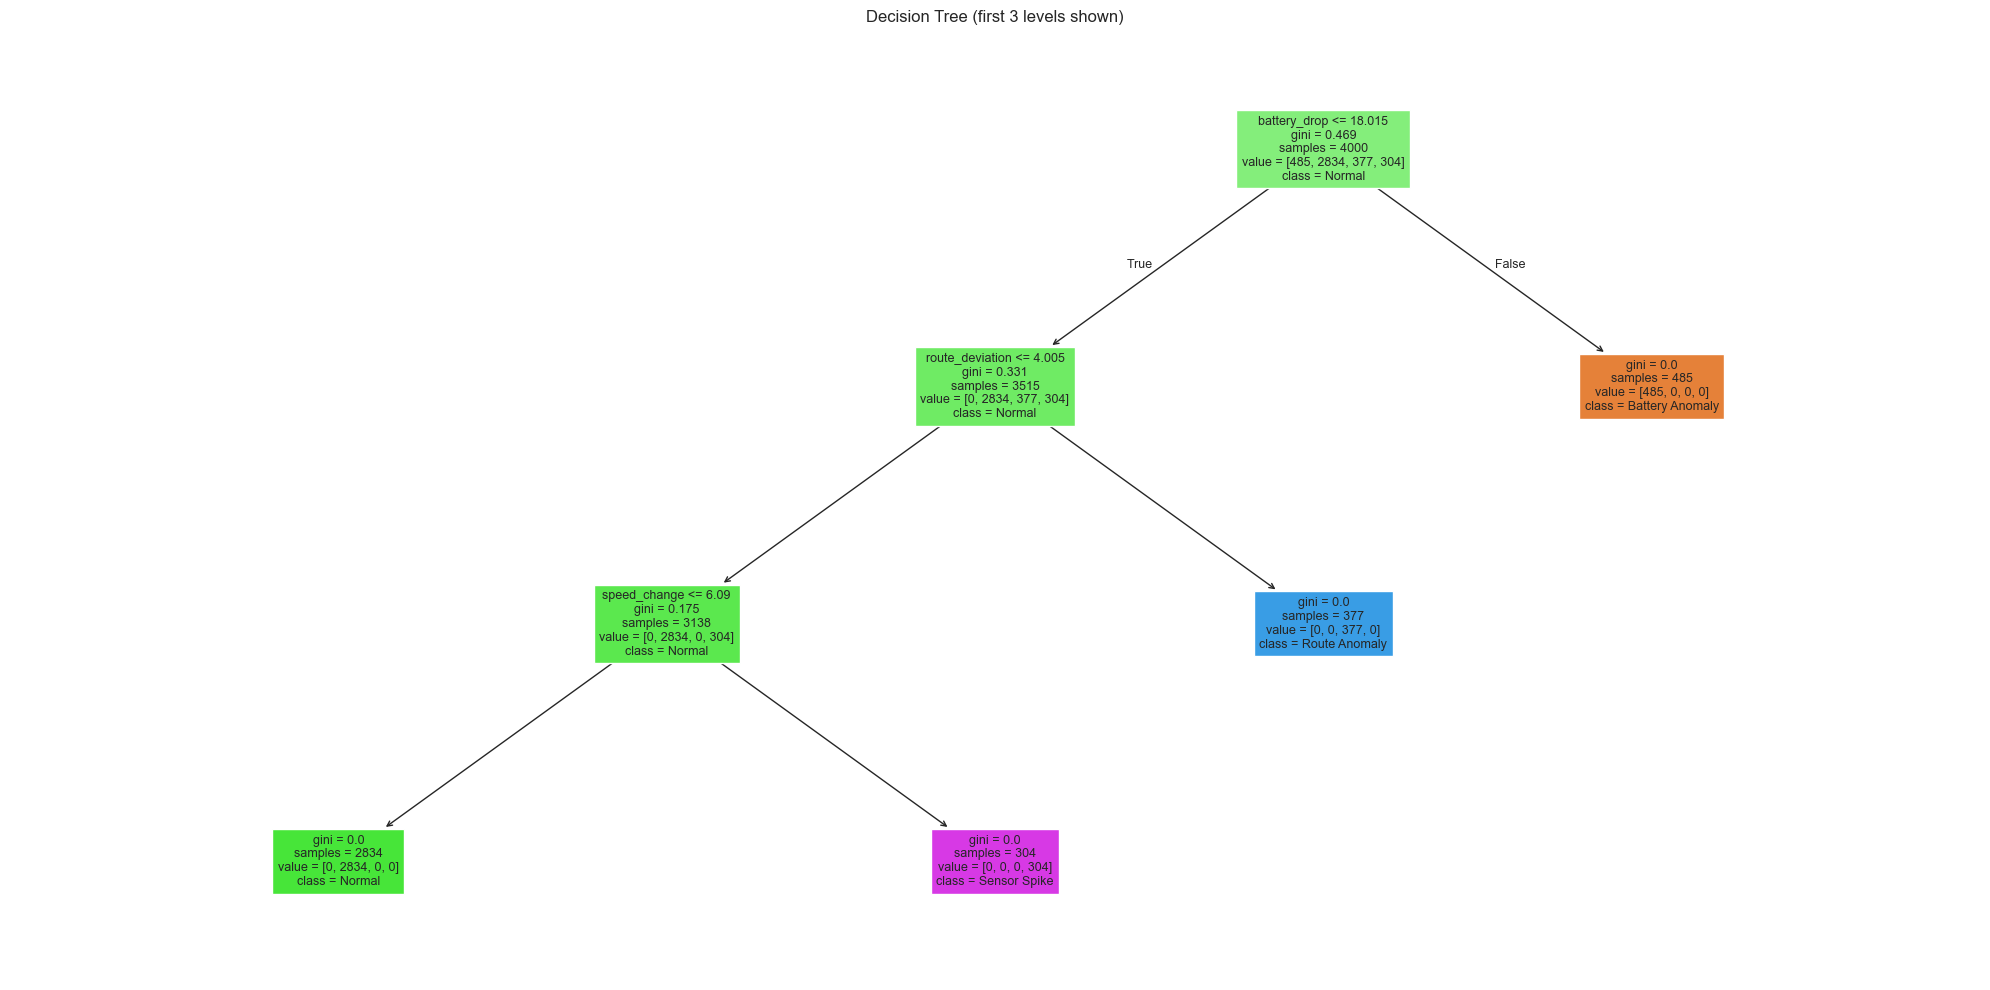

Decision tree visualization saved.


In [16]:
from sklearn import tree as sk_tree

plt.figure(figsize=(20, 10))
sk_tree.plot_tree(dt, feature_names=feature_cols, class_names=label_names,
                  filled=True, max_depth=3, fontsize=9)
plt.title('Decision Tree (first 3 levels shown)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'anomaly_decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Decision tree visualization saved.")

Cross-Validation

In [17]:
cv_dt = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_nb = cross_val_score(nb, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold CV Accuracy:")
print(f"  Decision Tree  : {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")
print(f"  Random Forest  : {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"  KNN            : {cv_knn.mean():.4f} ± {cv_knn.std():.4f}")
print(f"  Naive Bayes    : {cv_nb.mean():.4f} ± {cv_nb.std():.4f}")

5-Fold CV Accuracy:
  Decision Tree  : 1.0000 ± 0.0000
  Random Forest  : 1.0000 ± 0.0000
  KNN            : 0.9988 ± 0.0014
  Naive Bayes    : 1.0000 ± 0.0000



 Integration: Classify a Single Telemetry Record
 This function will be called from the main simulation when an anomaly check is needed (e.g., Step 18 of the 20-step demo).



In [18]:
def classify_anomaly(battery_level, battery_drop, altitude, altitude_change,
                     speed, speed_change, route_deviation):
    """
    Classify a single telemetry reading using the trained Random Forest.
    Returns (predicted_label, confidence).
    """
    x = pd.DataFrame([{
        'battery_level': battery_level, 'battery_drop': battery_drop,
        'altitude': altitude, 'altitude_change': altitude_change,
        'speed': speed, 'speed_change': speed_change,
        'route_deviation': route_deviation
    }])
    pred_class = rf.predict(x)[0]
    pred_proba = rf.predict_proba(x)[0]
    label = le.inverse_transform([pred_class])[0]
    confidence = pred_proba[pred_class]
    return label, round(confidence, 4)

# Demo — simulate the Step 18 anomaly event
print("=== Simulation Integration Demo ===\n")

# Normal flight
lbl, conf = classify_anomaly(82, 2.5, 48, 1.2, 7.5, 0.8, 0.5)
print(f"Normal flight   → {lbl} (confidence: {conf})")

# Battery anomaly
lbl, conf = classify_anomaly(45, 38.0, 50, 2.1, 8.0, 1.0, 1.2)
print(f"Battery drop    → {lbl} (confidence: {conf})")

# Route anomaly
lbl, conf = classify_anomaly(70, 3.0, 52, 1.5, 6.0, 0.5, 8.7)
print(f"Route deviation → {lbl} (confidence: {conf})")

# Sensor spike
lbl, conf = classify_anomaly(75, 2.0, 55, 22.0, 14.0, 11.0, 0.8)
print(f"Sensor spike    → {lbl} (confidence: {conf})")

=== Simulation Integration Demo ===

Normal flight   → Normal (confidence: 0.997)
Battery drop    → Battery Anomaly (confidence: 0.9675)
Route deviation → Route Anomaly (confidence: 0.9815)
Sensor spike    → Sensor Spike (confidence: 0.8538)


 Save the Final Model, Scaler, and Label Encoder


In [19]:
model_path  = os.path.join(PROC_DIR, 'anomaly_model.pkl')
scaler_path = os.path.join(PROC_DIR, 'anomaly_scaler.pkl')
encoder_path = os.path.join(PROC_DIR, 'anomaly_label_encoder.pkl')

with open(model_path, 'wb') as f:
    pickle.dump(rf, f)
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)

print(f" Model saved         → {model_path}")
print(f"Scaler saved        → {scaler_path}")
print(f"Label encoder saved → {encoder_path}")

 Model saved         → ..\data\processed\anomaly_model.pkl
Scaler saved        → ..\data\processed\anomaly_scaler.pkl
Label encoder saved → ..\data\processed\anomaly_label_encoder.pkl


Save the Synthetic Dataset (for reproducibility)

In [20]:
dataset_path = os.path.join(DATA_DIR, 'synthetic_drone_telemetry.csv')
df.to_csv(dataset_path, index=False)
print(f" Synthetic dataset saved → {dataset_path}")

 Synthetic dataset saved → ..\data\raw\synthetic_drone_telemetry.csv
